In [1]:
import os
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt 
import xarray as xr
import pandas as pd
import datetime

def wr(txt):
    w=open('日志.log','a')
    w.write(txt)
    w.close()


# http_proxy = "socks://127.0.0.1:20808"
# https_proxy = "socks://127.0.0.1:20808"
# os.environ['HTTP_PROXY'] = http_proxy
# os.environ['HTTPS_PROXY'] = https_proxy

# x 1499:1:2499
# y 949:1:1399
# z 0:1:33

In [ ]:
f=open(r'D:\OneDrive\heat_budget\MHW_HB\needs.txt','r')
a=f.readlines()
f.close()
def getdat(s):
    return s.split('.')[0].split('_')[-3]+'_'+s.split('.')[0].split('_')[-2]
temp_add=list(map(getdat,a))

In [ ]:
f=open(r'D:\OneDrive\heat_budget\MHW_HB\needs.txt','r')
a=f.readlines()
f.close()
def getdat(s):
    return s.split('.')[0].split('_')[-3]+'_'+s.split('.')[0].split('_')[-2]
temp_add=list(map(getdat,a))
def r2(s):
    return s[:-2]
wr(f'{datetime.datetime.now()}: Start Download : \n')
per=[
    [0,11],
    [11,22],
    [22,33]
]
ts=pd.date_range('19930101','20221231',freq='D')
num=64
print(temp_add)
for i in temp_add[num:]:
    print(temp_add[num])
    ml=ts[(ts.year==int(i.split("_")[0]))&(ts.month==int(i.split("_")[1]))].shape[0]-1
    
    # wr(f'{datetime.datetime.now()}:   MLD Download : ocean_mld_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc \n')
    # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_mld_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?mld[0:1:{ml}][949:1:1399][1499:1:2499]')
    # das.to_netcdf(rf'E:\OceanData\Bran\mld\ocean_mld_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    # wr(rf'{datetime.datetime.now()}:   MLD Down End : Save To E:\OceanData\Bran\mld\ocean_mld_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    # wr('\n')
    
    wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy \n')
    # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?temp[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # das.to_netcdf(rf'E:\OceanData\Bran\temp\ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    temp=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?temp[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['temp']) for j in per],axis=1))
    np.save(rf'F:\OceanData\Bran\temp2\ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy',temp)
    wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\temp2\ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy')
    wr('\n')
    
    # wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy \n')
    # #das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?u[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # #das.to_netcdf(rf'E:\OceanData\Bran\u\ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    # us=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?u[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['u']) for j in per],axis=1))
    # np.save(rf'F:\OceanData\Bran\u\ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy',us)
    # wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\u\ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy')
    # wr('\n')
    
    # wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy \n')
    # # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?v[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # # das.to_netcdf(rf'E:\OceanData\Bran\v\ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    # vs=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?v[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['v']) for j in per],axis=1))
    # np.save(rf'E:\OceanData\Bran\v\ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy',vs)
    # wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\v\ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy')
    # wr('\n')
    print(num)
    num+=1

    
    

In [ ]:

t=pd.date_range('19930101','20221231',freq='M')
ts=pd.date_range('19930101','20221231',freq='D')
per=[
    [0,16],
    [16,33]
]
num=35
nums=num
wr(f'{datetime.datetime.now()}: Start Download : \n')
for i in t[num:100]:
    ml=ts[(ts.year==i.year)&(ts.month==i.month)].shape[0]-1
    
    # wr(f'{datetime.datetime.now()}:   MLD Download : ocean_mld_{i.year}_{i.month:02d}.nc \n')
    # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_mld_{i.year}_{i.month:02d}.nc?mld[0:1:{ml}][949:1:1399][1499:1:2499]')
    # das.to_netcdf(rf'E:\OceanData\Bran\mld\ocean_mld_{i.year}_{i.month:02d}.nc')
    # wr(rf'{datetime.datetime.now()}:   MLD Down End : Save To E:\OceanData\Bran\mld\ocean_mld_{i.year}_{i.month:02d}.nc')
    # wr('\n')
    
    wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_temp_{i.year}_{i.month:02d}.npy \n')
    # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.year}_{i.month:02d}.nc?temp[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # das.to_netcdf(rf'E:\OceanData\Bran\temp\ocean_temp_{i.year}_{i.month:02d}.nc')
    temp=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.year}_{i.month:02d}.nc?temp[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['temp']) for j in per],axis=1))
    np.save(rf'E:\OceanData\Bran\temp\ocean_temp_{i.year}_{i.month:02d}.npy',temp)
    wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\temp\ocean_temp_{i.year}_{i.month:02d}.npy')
    wr('\n')
    
    wr(f'{datetime.datetime.now()}:  U     Download : ocean_u_{i.year}_{i.month:02d}.npy \n')
    #das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_u_{i.year}_{i.month:02d}.nc?u[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    #das.to_netcdf(rf'E:\OceanData\Bran\u\ocean_u_{i.year}_{i.month:02d}.nc')
    us=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_u_{i.year}_{i.month:02d}.nc?u[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['u']) for j in per],axis=1))
    np.save(rf'E:\OceanData\Bran\u\ocean_u_{i.year}_{i.month:02d}.npy',us)
    wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\u\ocean_u_{i.year}_{i.month:02d}.npy')
    wr('\n')
    
    wr(f'{datetime.datetime.now()}:  V    Download : ocean_v_{i.year}_{i.month:02d}.npy \n')
    # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{i.year}_{i.month:02d}.nc?v[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # das.to_netcdf(rf'E:\OceanData\Bran\v\ocean_v_{i.year}_{i.month:02d}.nc')
    vs=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{i.year}_{i.month:02d}.nc?v[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['v']) for j in per],axis=1))
    np.save(rf'E:\OceanData\Bran\v\ocean_v_{i.year}_{i.month:02d}.npy',vs)
    wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\v\ocean_v_{i.year}_{i.month:02d}.npy')
    wr('\n')
    nums+=1
    wr(str(nums))

    
    

In [ ]:
t=pd.date_range('19930101','20221231',freq='M')
ts=pd.date_range('19930101','20221231',freq='D')
num=34
nums=num
i=t[num]
ml=ts[(ts.year==i.year)&(ts.month==i.month)].shape[0]-1
per=[
    [0,16],
    [16,33]
]


wr(f'{datetime.datetime.now()}:  VDownload : ocean_v_{i.year}_{i.month:02d}.npy \n')
# das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{i.year}_{i.month:02d}.nc?v[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
# das.to_netcdf(rf'E:\OceanData\Bran\v\ocean_v_{i.year}_{i.month:02d}.nc')
vs=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{i.year}_{i.month:02d}.nc?v[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['v']) for j in per],axis=1))
np.save(rf'E:\OceanData\Bran\v\ocean_v_{i.year}_{i.month:02d}.npy',vs)
wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\v\ocean_v_{i.year}_{i.month:02d}.npy')
wr('\n')
nums+=1
wr(str(nums))

In [6]:
#das=nc.Dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_1993_1.nc?v[0:1:30][0][949:1:1399][1499:1:2499]')
das=nc.Dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_1993_01.nc?xt_ocean[1499:1:2499],yt_ocean[949:1:1399],st_ocean[0:1:33]')

In [7]:
das.variables.keys()

dict_keys(['xt_ocean', 'yt_ocean', 'st_ocean'])

In [9]:
lon=np.array(das['xt_ocean'])
lat=np.array(das['yt_ocean'])
level=np.array(das['st_ocean'])
#temp=np.array(das['temp'])
Lon,Lat=np.meshgrid(lon,lat)

In [ ]:
np.savez('BRAN_lon_lat_level.npz',lon=lon,lat=lat,level=level)

In [ ]:
plt.contourf(Lon,Lat,temp[0,0,:,:])

In [ ]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': [
            'mean_surface_latent_heat_flux', 'mean_surface_net_long_wave_radiation_flux', 'mean_surface_net_short_wave_radiation_flux',
            'mean_surface_sensible_heat_flux',
        ],
        'year': '2022',
        'month': [
            '01', '02', '03',
            '04', '05', '06',
            '07', '08', '09',
            '10', '11', '12',
        ],
        'day': [
            '01', '02', '03',
            '04', '05', '06',
            '07', '08', '09',
            '10', '11', '12',
            '13', '14', '15',
            '16', '17', '18',
            '19', '20', '21',
            '22', '23', '24',
            '25', '26', '27',
            '28', '29', '30',
            '31',
        ],
        'time': [
            '00:00', '01:00', '02:00',
            '03:00', '04:00', '05:00',
            '06:00', '07:00', '08:00',
            '09:00', '10:00', '11:00',
            '12:00', '13:00', '14:00',
            '15:00', '16:00', '17:00',
            '18:00', '19:00', '20:00',
            '21:00', '22:00', '23:00',
        ],
        'area': [
            60, 150, 20,
            180,
        ],
        'format': 'netcdf',
    },
    'test.nc')

In [2]:
das=nc.Dataset(r'C:\Users\XUEX\Downloads\adaptor.mars.internal-1683795181.3008213-21168-11-04bf4afd-5eba-43b1-badf-e9d2d09caa54.nc')

In [3]:
das.variables.keys()

dict_keys(['longitude', 'latitude', 'time', 'msdwlwrf', 'msnlwrf', 'slhf'])

In [ ]:
das['mslhf']

In [ ]:
das['slhf']

In [6]:
msdwlwrf=np.array(das['msdwlwrf'])
msnlwrf=np.array(das['msnlwrf'])

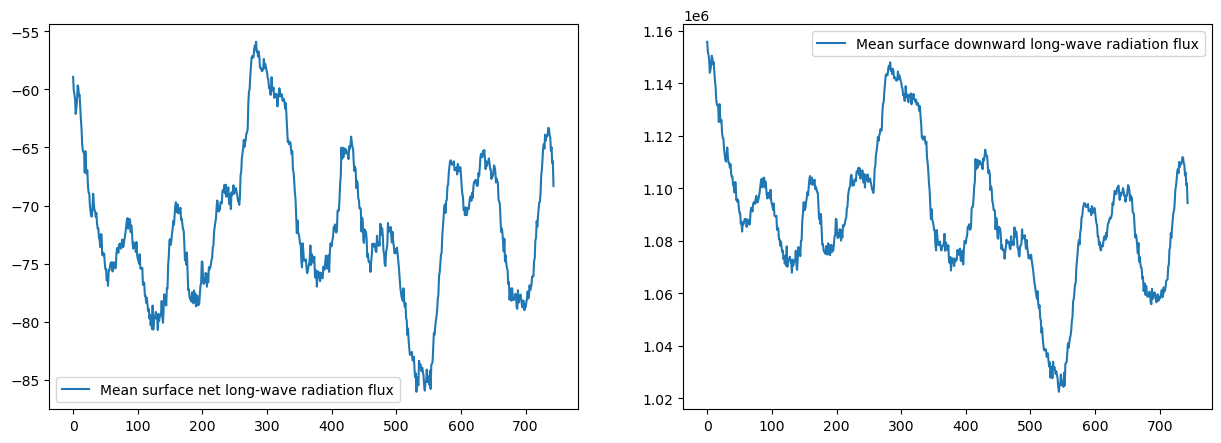

In [19]:
#plt.plot(np.mean(np.mean(msdwlwrf,axis=-1)*3600,axis=-1))
plt.figure(figsize=[15,5])
plt.subplot(1,2,1)
plt.plot(np.mean(np.mean(msnlwrf,axis=-1),axis=-1),label='Mean surface net long-wave radiation flux')
plt.legend()
plt.subplot(1,2,2)
plt.plot(np.mean(np.mean(msdwlwrf,axis=-1)*3600,axis=-1),label='Mean surface downward long-wave radiation flux')
plt.legend()

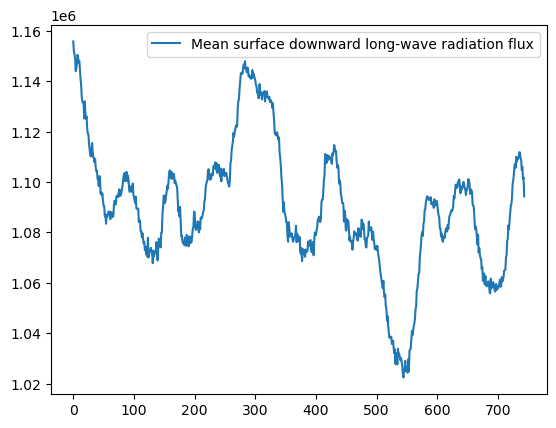

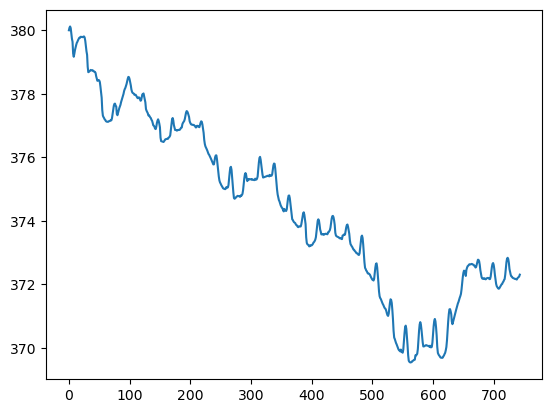

In [21]:
plt.plot(np.mean(np.mean(msdwlwrf,axis=-1),axis=-1)-np.mean(np.mean(msnlwrf,axis=-1),axis=-1))

In [1]:
def getdat(year):
    import cdsapi
    c = cdsapi.Client()
    # c.retrieve(
    #     'reanalysis-era5-single-levels',
    #     {
    #         'product_type': 'reanalysis',
    #         'variable': [
    #             'mean_surface_latent_heat_flux', 'mean_surface_net_long_wave_radiation_flux', 'mean_surface_net_short_wave_radiation_flux',
    #             'mean_surface_sensible_heat_flux', 'surface_latent_heat_flux',
    #         ],
    #         'year': f'{year}',
    #         'month': [
    #             '01', '02', '03',
    #             '04', '05', '06',
    #             '07', '08', '09',
    #             '10', '11', '12',
    #         ],
    #         'day': [
    #             '01', '02', '03',
    #             '04', '05', '06',
    #             '07', '08', '09',
    #             '10', '11', '12',
    #             '13', '14', '15',
    #             '16', '17', '18',
    #             '19', '20', '21',
    #             '22', '23', '24',
    #             '25', '26', '27',
    #             '28', '29', '30',
    #             '31',
    #         ],
    #         'time': [
    #             '00:00', '06:00', '12:00',
    #             '18:00',
    #         ],
    #         'area': [
    #             60, 150, 20,
    #             180,
    #         ],
    #         'format': 'netcdf',
    #     },
    #     f'{year}_150E_180.nc')
    c.retrieve(
        'reanalysis-era5-single-levels',
        {
            'product_type': 'reanalysis',
            'variable': [
                'mean_surface_latent_heat_flux', 'mean_surface_net_long_wave_radiation_flux', 'mean_surface_net_short_wave_radiation_flux',
                'mean_surface_sensible_heat_flux', 'surface_latent_heat_flux',
            ],
            'year': f'{year}',
            'month': [
                '01', '02', '03',
                '04', '05', '06',
                '07', '08', '09',
                '10', '11', '12',
            ],
            'day': [
                '01', '02', '03',
                '04', '05', '06',
                '07', '08', '09',
                '10', '11', '12',
                '13', '14', '15',
                '16', '17', '18',
                '19', '20', '21',
                '22', '23', '24',
                '25', '26', '27',
                '28', '29', '30',
                '31',
            ],
            'time': [
                '00:00', '06:00', '12:00',
                '18:00',
            ],
            'area': [
                60, -180, 20,
                -110,
            ],
            'format': 'netcdf',
        },
        f'{year}_0_70W.nc')
#getdat(2022)

In [3]:

getdat(2022)

2023-05-18 17:37:03,351 INFO Welcome to the CDS
2023-05-18 17:37:03,352 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels
2023-05-18 17:37:03,653 INFO Request is queued
2023-05-18 17:37:04,931 INFO Request is running
2023-05-18 17:45:27,654 INFO Request is completed
2023-05-18 17:45:27,655 INFO Downloading https://download-0004-clone.copernicus-climate.eu/cache-compute-0004/cache/data8/adaptor.mars.internal-1684403012.643095-2134-18-7ec74f69-4623-4ac6-93ef-cf555899c999.nc to 2022_0_70W.nc (629.9M)
2023-05-18 17:48:25,901 INFO Download rate 3.5M/s    


In [2]:
for i in range(2011,2017):
    getdat(i)

2023-05-18 15:52:50,957 INFO Welcome to the CDS
2023-05-18 15:52:50,958 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels
2023-05-18 15:52:51,426 INFO Request is completed
2023-05-18 15:52:51,427 INFO Downloading https://download-0009-clone.copernicus-climate.eu/cache-compute-0009/cache/data7/adaptor.mars.internal-1684393363.80584-32358-7-b0d0de39-e260-4645-ac21-46e7145086ba.nc to 2011_0_70W.nc (629.9M)
2023-05-18 15:56:44,081 INFO Download rate 2.7M/s    
2023-05-18 15:56:45,491 INFO Welcome to the CDS
2023-05-18 15:56:45,492 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels
2023-05-18 15:56:45,825 INFO Request is queued
2023-05-18 15:56:47,128 INFO Request is running
2023-05-18 16:05:09,881 INFO Request is completed
2023-05-18 16:05:09,883 INFO Downloading https://download-0021.copernicus-climate.eu/cache-compute-0021/cache/data6/adaptor.mars.internal-1684396980.863858-15256-